In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import ImageGrid
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import numpy as np

import patato as pat
from PIL import Image

import scienceplots  # noqa
from pathlib import Path

from paiskintonetools import setup_matplotlib  #  type:ignore
from paiskintonetools.stats import p_formatter  # type: ignore

import statsmodels.formula.api as smf

setup_matplotlib(dpi=200)
plt.style.use(["vibrant"])

In [2]:
import json

settings = json.load(open("../data_paths.json", "r"))
root_data_path = (Path.cwd() / "../" / settings["vitiligo_data_path"]).resolve()

scan = root_data_path / "SKIN33/Scan_3.hdf5"
pat_vitiligo = pat.PAData.from_hdf5(scan)
pat_vitiligo.set_default_recon(("Model Based", "0"))  # type: ignore
xs = pat_vitiligo.get_scan_reconstructions().da.coords["x"].values  # type: ignore
pa_weighting = np.exp(xs * 100)

In [3]:
forearm_wood = Image.open("figures/skin36_uv.jpg")
forearm_light = Image.open("figures/skin36_light.jpg")

In [4]:
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

In [5]:
df = pd.read_parquet("../01_Prepare Data/tables/pa_values_extracted_all_meta.parquet")
df = df.query("`Fitzpatrick Type` == 'Vitiligo'")
df = df.query("`ROI Name` == 'skin'")
df["pa"] = df["spectrum_mean"].apply(lambda x: x[0])
df["PA 700 nm"] = df["spectrum_mean"].apply(lambda x: x[0])

df = (
    df.groupby(["SkinID", "Region", "Pigment", "Side"])
    .mean(numeric_only=True)
    .reset_index()
)

In [6]:
def get_position(x):
    if x in ["Radial Artery", "Brachial Artery", "Ulnar Artery"]:
        return "Forearm"
    else:
        return x


colors = {x: f"C{i}" for i, x in enumerate(sorted(pd.unique(df["SkinID"])))}
handles = [
    Line2D([], [], color=c, marker="o", markersize=5, label=y)
    for y, c in colors.items()
]
labels = list([x[-2:] for x in colors.keys()])

df["Colour"] = df["SkinID"].apply(lambda x: colors[x])

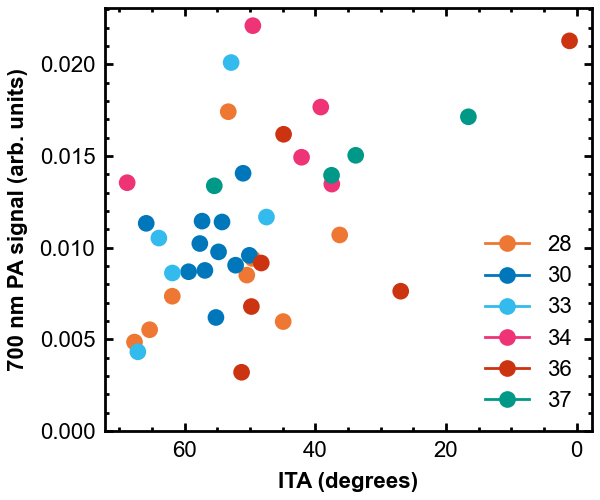

In [7]:
fig, ax = plt.subplots(figsize=(3, 2.5))
ax.scatter(df["ITA"], df["pa"], c=df["Colour"])
ax.invert_xaxis()
ax.legend(handles, labels, loc="lower right")
ax.set_xlabel("ITA (degrees)")
ax.set_ylabel("700 nm PA signal (arb. units)")
ax.set_ylim([0, None])
plt.show()

In [8]:
df[["SkinID", "Region", "Pigment", "Side"]].to_csv("tables/test.csv")

In [9]:
df_pig_not_pig = pd.read_csv(
    "tables/similar_sites_pigmented_not_pigmented.csv", index_col=0
)
df_pig_not_pig = df_pig_not_pig[~pd.isna(df_pig_not_pig["PairedPigment"])]
df_pig_not_pig.loc[pd.isna(df_pig_not_pig["Pigment"]), "Pigment"] = ""
df_pig_not_pig.loc[pd.isna(df_pig_not_pig["Side"]), "Side"] = ""
# This table contains pairs of similar sites (e.g. different positions on the forearm, labeled as pigmented or not pigmented).

df_pig_included = df.merge(df_pig_not_pig, on=["SkinID", "Region", "Pigment", "Side"])
df_pig_included["PA Melanin"] = df_pig_included["pa"]
df_pig_included_averaged = (
    df_pig_included.groupby(["SkinID", "Region", "PairedPigment"])
    .mean(numeric_only=True)
    .reset_index()
)

# del df_pig_included["Pigment"] # Make sure not to confuse old code

/Users/telse/Documents/Code/CambridgeBits/PAISKINTONE/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/telse/Documents/Code/CambridgeBits/PAISKINTONE/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


<class 'statsmodels.iolib.summary2.Summary'>
"""
                       Mixed Linear Model Regression Results
====================================================================================
Model:                      MixedLM           Dependent Variable:           ITA     
No. Observations:           15                Method:                       REML    
No. Groups:                 6                 Scale:                        26.5238 
Min. group size:            2                 Log-Likelihood:               -50.0504
Max. group size:            4                 Converged:                    Yes     
Mean group size:            2.5                                                     
------------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
------------------------------------------------------------------------------------
Intercept                               58.311    6.605  8.828 0.000  45.364  71.257
PairedPigment[T.Pigmented]             -21.018    3.100 -6.780 0.000 -27.094 -14.942
Group Var                              235.867   48.265                             
Group x PairedPigment[T.Pigmented] Cov  51.167   12.966                             
PairedPigment[T.Pigmented] Var          11.100   12.045                             
====================================================================================

"""

1.2051080614462208e-11

/Users/telse/Documents/Code/CambridgeBits/PAISKINTONE/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/telse/Documents/Code/CambridgeBits/PAISKINTONE/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/telse/Documents/Code/CambridgeBits/PAISKINTONE/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/telse/Documents/Code/CambridgeBits/PAISKINTONE/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)

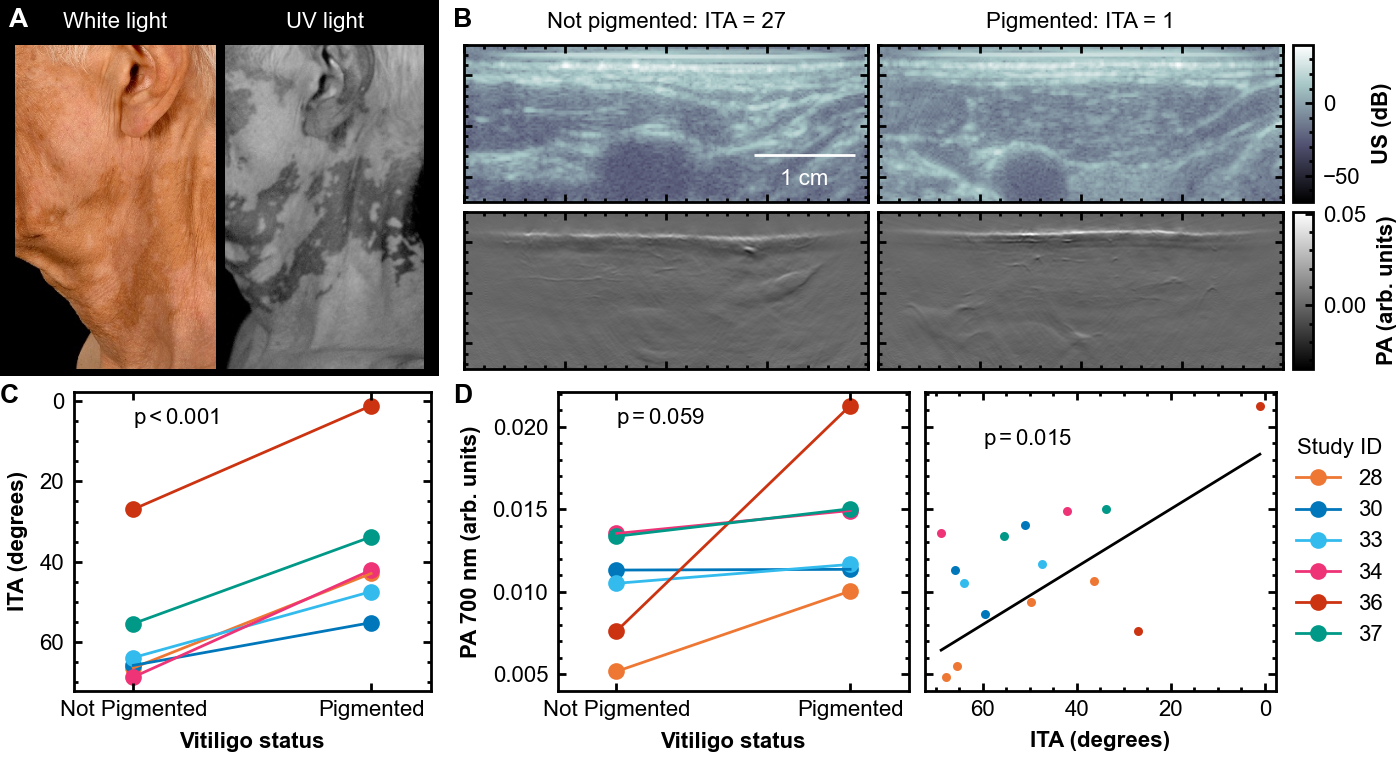

In [10]:
fig = plt.figure(figsize=(7, 4 * 0.95), constrained_layout=True)

subfiga, subfigb = fig.subfigures(2)

subfig_photos, subfig_pa = subfiga.subfigures(1, 2, width_ratios=[0.95, 2.05])
subfig_pa.text(
    0, 1 - 0.02, "B", va="top", ha="left", fontsize="large", fontweight="bold"
)
imgrid = ImageGrid(
    subfig_pa,
    (0.01, 0.02, 0.9, 0.86),
    nrows_ncols=(2, 2),
    axes_pad=0.05,
    share_all=True,
    cbar_mode="edge",
)

for ax in imgrid:
    ax.yaxis.set_tick_params(labelleft=False)
    ax.xaxis.set_tick_params(labelbottom=False)

axus = imgrid[:2]
axpa = imgrid[2:]

scans = ["SKIN36/Scan_21.hdf5", "SKIN36/Scan_18.hdf5"]
ims = []

test = df.set_index(["SkinID", "Region", "Pigment", "Side"])
itas = [
    test.loc[("SKIN36", "Carotid Artery", "Not Pigmented", ""), "ITA"],
    test.loc[("SKIN36", "Carotid Artery", "Pigmented", ""), "ITA"],
]
for ax_us, ax_pa, scan, letter, ita, site in zip(
    axus, axpa, scans, "BC", itas, ["Not pigmented", "Pigmented"]
):
    pat_vitiligo = pat.PAData.from_hdf5(root_data_path / scan)
    pat_vitiligo.set_default_recon(("Model Based", "0"))  # type: ignore
    rec = pat_vitiligo.get_scan_reconstructions()
    rec.raw_data = rec.raw_data / pa_weighting[None, None, :, None, None]  # type: ignore
    ax_us.set_ylim([-0.0075, 0.008])
    us = pat_vitiligo.get_ultrasound()
    im_us = ax_us.imshow(
        np.squeeze(us.raw_data[0, 0]),  # type: ignore
        extent=us.extent,  # type: ignore
        origin="lower",
        cmap="bone",
    )
    im_pa = ax_pa.imshow(
        np.squeeze(rec.raw_data[0, 0]),  # type: ignore
        extent=rec.extent,  # type: ignore
        origin="lower",
        cmap="gray",
    )
    ims.append(im_pa)
    # ax_us.set_title(letter, loc="left")
    ax_us.set_title(f"{site}: ITA = {ita:.0f}", fontweight="normal", fontsize="medium")

    ax_us.yaxis.set_tick_params(labelleft=False)
    ax_us.xaxis.set_tick_params(labelbottom=False)
    ax_pa.yaxis.set_tick_params(labelleft=False)
    ax_pa.xaxis.set_tick_params(labelbottom=False)

# so2s_calculated = ["(87.4 ± 1.5) %", "(92.4 ± 3.1) %"]  # from skin36comparisons.ipynb

# for j, s in enumerate(scans):
#     p = pat.PAData.from_hdf5(s)
#     ra = p.get_rois()["artery_", "0"]
#     xyra = np.squeeze(np.array(ra.get_polygon().centroid.xy))
#     miny = np.argmax(ra.points[:, 1] - np.abs(xyra[0] - ra.points[:, 0]))

#     xyarrow = ra.points[miny]
#     direction = xyarrow - xyra
#     direction /= np.linalg.norm(direction) / 10
#     axus[j].annotate(
#         so2s_calculated[j],
#         xyarrow,
#         direction,
#         textcoords="offset points",
#         fontsize="small",
#         fontweight="bold",
#         arrowprops={
#             "width": 1,
#             "headwidth": 5,
#             "headlength": 3,
#             "facecolor": "k",
#             "edgecolor": "k",
#         },
#     )

asb = AnchoredSizeBar(
    axus[0].transData,
    0.01,
    "1 cm",
    loc="lower right",
    pad=0.1,
    borderpad=0.5,
    sep=5,
    frameon=False,
    color="white",
)
axus[0].add_artist(asb)

clim = [min([i.get_clim()[0] for i in ims]), max([i.get_clim()[1] for i in ims])]
for i in ims:
    i.set_clim(clim)

imgrid.cbar_axes[0].colorbar(im_us, label="US (dB)")  # type: ignore
imgrid.cbar_axes[1].colorbar(ims[0], label="PA (arb. units)")

# plt.colorbar(ims[0], ax=axpa, label="PA (arb. units)", aspect=10)
# cbar_us = plt.colorbar(im_us, ax=axus, label="US (dB)", aspect=10)
# cbar_us.ax.yaxis.set_tick_params(which="minor", right=False)
# cbar_us.ax.yaxis.set_ticks(list(cbar_us.ax.get_ylim()), ["MIN", "MAX"])

subfig_photos.set_facecolor("k")
ax1, ax2 = ImageGrid(
    subfig_photos, (0.02, 0.02, 0.96, 0.86), nrows_ncols=(1, 2), axes_pad=0.05
)


ax1.imshow(forearm_light)
# ax1.set_title("Daylight", fontsize="medium")
subfig_photos.text(
    0.02,
    1 - 0.02,
    "A",
    va="top",
    ha="left",
    fontsize="large",
    fontweight="bold",
    color="white",
)
ax1.axis("off")
ax2.axis("off")

ax1.set_title("White light", color="w", fontweight="normal", fontsize="medium")
ax2.set_title("UV light", color="w", fontweight="normal", fontsize="medium")

# ax1.set_ylim([215, 55])
ax2.imshow(forearm_wood)
ax1.set_xlim([50, forearm_light.size[0] - 10])
ax2.set_xlim([50, forearm_wood.size[0] - 10])
ax1.set_ylim([None, 60])
ax2.set_ylim([None, 60])

# ax2.annotate(
#     "Pigmented",
#     (180, 290),
#     (-10, 20),
#     va="bottom",
#     ha="left",
#     textcoords="offset points",
#     color="white",
#     fontsize="small",
#     arrowprops=dict(arrowstyle="->", connectionstyle="arc3", edgecolor="white"),
# )
# ax2.annotate(
#     "Not\npigmented",
#     (200, 320),
#     (0.65, 0.025),
#     va="bottom",
#     ha="center",
#     textcoords=ax2.transAxes,
#     color="white",
#     fontsize="small",
#     arrowprops=dict(arrowstyle="->", connectionstyle="arc3", edgecolor="white"),
# )

# ax2.annotate("Not pigmented", (430, 140), (-70, -30), textcoords="offset points", color="white", fontsize="small", arrowprops=dict(arrowstyle="->", connectionstyle="arc3", edgecolor="white"))

subfigb1, subfigb2 = subfigb.subfigures(1, 2, width_ratios=[0.95, 2.05])
axes = subfigb2.subplots(1, 2)
axes[0].sharey(axes[1])

ax = subfigb1.subplots()
subfigb1.text(0, 1, "C", va="top", ha="left", fontsize="large", fontweight="bold")
for n, g in df_pig_included_averaged.groupby("SkinID"):
    ax.scatter(g["PairedPigment"], g["ITA"], color=colors[n])
    ax.plot(g["PairedPigment"], g["ITA"], color=colors[n])
ax.invert_yaxis()
ax.set_ylabel("ITA (degrees)")
ax.set_xlabel("Vitiligo status")
ax.xaxis.set_tick_params(which="minor", top=False, bottom=False)
ax.set_xlim(-0.25, 1.25)

md = smf.mixedlm(
    "ITA ~ PairedPigment",
    df_pig_included,
    groups=df_pig_included["SkinID"],
    re_formula="~PairedPigment",
)
mdf = md.fit()
display(mdf.summary())

p = mdf.pvalues["PairedPigment[T.Pigmented]"]
display(p)

ax.text(0, np.min(df_pig_included["ITA"]), p_formatter(p), ha="left", va="top")

ax = axes[0]
for n, g in df_pig_included_averaged.groupby("SkinID"):
    ax.scatter(g["PairedPigment"], g["PA Melanin"], color=colors[n])
    ax.plot(g["PairedPigment"], g["PA Melanin"], color=colors[n])

df_pig_included["y"] = df_pig_included["PA Melanin"]
md = smf.mixedlm(
    "y ~ PairedPigment",
    df_pig_included,
    groups=df_pig_included["SkinID"],
    re_formula="~PairedPigment",
)
mdf = md.fit()

p = mdf.pvalues["PairedPigment[T.Pigmented]"]
ax.text(0, np.max(df_pig_included["PA Melanin"]), p_formatter(p), ha="left", va="top")

subfigb2.text(0, 1, "D", va="top", ha="left", fontsize="large", fontweight="bold")

ax.set_ylabel("PA 700 nm (arb. units)")
ax.set_xlabel("Vitiligo status")

ax.xaxis.set_tick_params(which="minor", top=False, bottom=False)
ax.set_xlim(-0.25, 1.25)

ax = axes[1]

for n, g in df_pig_included.groupby("SkinID"):
    ax.scatter(g["ITA"], g["PA Melanin"], color=colors[n], s=5)
ax.invert_xaxis()

df_pig_included["y"] = df_pig_included["PA Melanin"]
md = smf.mixedlm(
    "y ~ ITA", df_pig_included, groups=df_pig_included["SkinID"], re_formula="~ITA"
)
mdf = md.fit()
df_clear = pd.DataFrame(
    {"ITA": np.linspace(np.min(df_pig_included["ITA"]), np.max(df_pig_included["ITA"]))}
)
df_clear["y"] = mdf.predict(df_clear)

ax.plot(df_clear["ITA"], df_clear["y"], c="k")

ax.set_xlabel("ITA (degrees)")
# ax.set_ylabel("PA melanin (arb. units)")
ax.yaxis.set_tick_params(labelleft=False)
p = mdf.pvalues["ITA"]

ax.text(60, 0.02, p_formatter(p), ha="left", va="top")
ax.legend(
    handles,
    labels,
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    title="Study ID",
)

plt.show()

In [11]:
fig.savefig("figures/figure4.pdf", dpi=300)
fig.savefig("figures/figure4.svg", dpi=300)

In [12]:
df_pig_included_averaged[["SkinID", "PairedPigment", "ITA", "PA 700 nm"]].to_csv(
    "../Analysis/plotted_data/figure4.csv"
)